# 02. Regression metric comparison with XGBoost

**Purpose.** Rebuild scaffold folds from processed regression datasets, train XGBoost regressors, and compare no-scaffold test performance with ordinary-fold references.

**Datasets.** Boiling point and pKb.

**Main outputs.**
- `target_shift_summary.csv`
- `ordinary_vs_no_scaffold_regression_metrics.csv`
- `ordinary_vs_no_scaffold_regression_metric_ratios.csv`

**Expected observation.** Raw error metrics and scale-normalized relMAE can give different views when target scales differ across datasets or subsets.

**Data source.** `data/demo/scaffold_from_scratch/`

In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs, rdBase, RDLogger
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold

import xgboost as xgb

rdBase.BlockLogs()
RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "demo" / "scaffold_from_scratch"
OUT_DIR = PROJECT_ROOT / "outputs" / "notebooks" / "regression_metric_comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 10086
FP_BITS = 1024
NUM_BOOST_ROUND = 80

DATASETS = [
    {"dataset": "bp", "display": "Boiling point", "path": DATA_DIR / "bp.csv", "target": "label"},
    {"dataset": "pkb", "display": "pKb", "path": DATA_DIR / "pkb.csv", "target": "label"},
]

print(f"Project root: {PROJECT_ROOT.name}")
print(f"Input directory: {DATA_DIR.relative_to(PROJECT_ROOT)}")
print(f"Output directory: {OUT_DIR.relative_to(PROJECT_ROOT)}")

Project root: empty-scaffold
Input directory: data/demo/scaffold_from_scratch
Output directory: outputs/notebooks/regression_metric_comparison


## Helper functions

In [2]:
NO_SCAFFOLD_LABELS = {"No_Scaffold"}


def normalize_smiles(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    try:
        return Chem.MolToSmiles(Chem.rdmolops.RemoveHs(mol))
    except Exception:
        return None


def murcko_scaffold(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return "Invalid_SMILES"
    try:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        if scaffold is None or scaffold.GetNumAtoms() == 0:
            return "No_Scaffold"
        return Chem.MolToSmiles(scaffold)
    except Exception:
        return "Error"


def annotate_scaffolds(df, smiles_col="molecules"):
    out = df.copy().reset_index(drop=True)
    out["SMILES_norm"] = out[smiles_col].map(normalize_smiles)
    out = out.dropna(subset=["SMILES_norm"]).reset_index(drop=True)
    out["scaffold"] = out["SMILES_norm"].map(murcko_scaffold)
    out["no_scaffold"] = out["scaffold"].isin(NO_SCAFFOLD_LABELS)
    out["scaffold_group"] = np.where(out["no_scaffold"], "__NO_SCAFFOLD__", out["scaffold"])
    return out


def scaffold_kfolds_for_n(n):
    if n <= 1000:
        return 5
    if n <= 3000:
        return 7
    return 10


def assign_scaffold_folds(df, n_folds, seed=10086):
    out = df.copy().reset_index(drop=True)
    rng = np.random.RandomState(seed)
    groups = []
    for group, idx in out.groupby("scaffold_group", sort=False).groups.items():
        groups.append((str(group), list(idx)))
    if len(groups) < n_folds:
        raise ValueError(f"number of scaffold groups ({len(groups)}) is smaller than n_folds={n_folds}")
    rng.shuffle(groups)
    groups = sorted(groups, key=lambda item: len(item[1]), reverse=True)

    fold_sizes = [0 for _ in range(n_folds)]
    fold_ids = np.empty(len(out), dtype=int)
    for fold, (_, idx) in enumerate(groups[:n_folds]):
        fold_ids[idx] = fold
        fold_sizes[fold] += len(idx)
    for _, idx in groups[n_folds:]:
        min_size = min(fold_sizes)
        candidates = [i for i, size in enumerate(fold_sizes) if size == min_size]
        fold = int(rng.choice(candidates))
        fold_ids[idx] = fold
        fold_sizes[fold] += len(idx)

    perm = np.arange(n_folds)
    rng.shuffle(perm)
    remap = {old: int(new) for old, new in zip(range(n_folds), perm)}
    out["fold"] = np.asarray([remap[int(f)] for f in fold_ids], dtype=int)
    return out


def no_scaffold_fold(folded):
    return int(folded.groupby("fold")["no_scaffold"].sum().idxmax())


def fold_allocation_summary(folded, dataset):
    rows = []
    for fold, part in folded.groupby("fold", sort=True):
        n_total = len(part)
        n_ns = int(part["no_scaffold"].sum())
        rows.append({
            "dataset": dataset,
            "fold": int(fold),
            "n_total": int(n_total),
            "n_no_scaffold": n_ns,
            "no_scaffold_fraction": n_ns / n_total if n_total else np.nan,
        })
    return pd.DataFrame(rows)

In [3]:
def mol_to_fp(smiles, n_bits=1024):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    try:
        return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits)
    except Exception:
        return None


def add_fingerprints(df, n_bits=1024):
    fps = []
    keep = []
    for i, smi in enumerate(df["SMILES_norm"].tolist()):
        fp = mol_to_fp(smi, n_bits=n_bits)
        if fp is not None:
            keep.append(i)
            fps.append(fp)
    out = df.iloc[keep].copy().reset_index(drop=True)
    out["fp"] = fps
    return out


def fp_matrix(fps, n_bits=1024):
    arr = np.zeros((len(fps), n_bits), dtype=np.float32)
    for i, fp in enumerate(fps):
        DataStructs.ConvertToNumpyArray(fp, arr[i])
    return arr


def fit_predict_xgboost_regression(train_df, test_df, target_col, n_bits=1024, seed=42, num_boost_round=80):
    train_df = train_df.dropna(subset=[target_col]).copy()
    test_df = test_df.dropna(subset=[target_col]).copy()
    if len(train_df) == 0 or len(test_df) == 0:
        raise ValueError("empty train or test table")

    x_train = fp_matrix(train_df["fp"].tolist(), n_bits=n_bits)
    y_train = train_df[target_col].astype(float).to_numpy()
    x_test = fp_matrix(test_df["fp"].tolist(), n_bits=n_bits)
    y_test = test_df[target_col].astype(float).to_numpy()

    y_mean = float(np.mean(y_train))
    y_std = float(np.std(y_train))
    if y_std == 0:
        y_std = 1.0
    y_train_s = (y_train - y_mean) / y_std

    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "eta": 0.05,
        "max_depth": 3,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "seed": int(seed),
        "nthread": 1,
    }
    booster = xgb.train(
        params,
        xgb.DMatrix(x_train, label=y_train_s),
        num_boost_round=num_boost_round,
        verbose_eval=False,
    )
    pred_s = booster.predict(xgb.DMatrix(x_test))
    pred = pred_s * y_std + y_mean

    out = test_df.copy()
    out["y_true"] = y_test
    out["y_pred"] = pred
    return out

In [4]:
def finite_arrays(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return y_true[mask], y_pred[mask]


def average_ranks(values):
    values = np.asarray(values, dtype=float)
    order = np.argsort(values, kind="mergesort")
    ranks = np.empty(len(values), dtype=float)
    i = 0
    while i < len(values):
        j = i + 1
        while j < len(values) and values[order[j]] == values[order[i]]:
            j += 1
        ranks[order[i:j]] = (i + 1 + j) / 2.0
        i = j
    return ranks


def pearson_r(x, y):
    x, y = finite_arrays(x, y)
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def spearman_rho(x, y):
    x, y = finite_arrays(x, y)
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return pearson_r(average_ranks(x), average_ranks(y))


def regression_metrics(y_true, y_pred):
    y_true, y_pred = finite_arrays(y_true, y_pred)
    if len(y_true) == 0:
        return {
            "n": 0, "MAE": np.nan, "RMSE": np.nan, "R2": np.nan,
            "Pearson_r": np.nan, "Spearman_rho": np.nan,
            "target_scale_mean_abs": np.nan, "relMAE": np.nan,
        }
    residual = y_true - y_pred
    mae = float(np.mean(np.abs(residual)))
    rmse = float(np.sqrt(np.mean(residual ** 2)))
    denom = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = float(1.0 - np.sum(residual ** 2) / denom) if denom > 0 and len(y_true) >= 2 else np.nan
    scale = float(np.mean(np.abs(y_true)))
    relmae = mae / scale if scale > 0 else np.nan
    return {
        "n": int(len(y_true)),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Pearson_r": pearson_r(y_true, y_pred),
        "Spearman_rho": spearman_rho(y_true, y_pred),
        "target_scale_mean_abs": scale,
        "relMAE": relmae,
    }


def ks_statistic(x, y):
    x = np.sort(np.asarray(x, dtype=float))
    y = np.sort(np.asarray(y, dtype=float))
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan
    values = np.sort(np.unique(np.concatenate([x, y])))
    cdf_x = np.searchsorted(x, values, side="right") / len(x)
    cdf_y = np.searchsorted(y, values, side="right") / len(y)
    return float(np.max(np.abs(cdf_x - cdf_y)))


def hedges_g(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    sx2 = float(np.var(x, ddof=1))
    sy2 = float(np.var(y, ddof=1))
    pooled = math.sqrt(((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2))
    if pooled == 0:
        return np.nan
    cohen_d = (float(np.mean(x)) - float(np.mean(y))) / pooled
    correction = 1.0 - 3.0 / (4.0 * (nx + ny) - 9.0)
    return float(cohen_d * correction)

## Load data and rebuild scaffold folds

In [5]:
folded_tables = {}
allocation_rows = []
shift_rows = []

for spec in DATASETS:
    raw = pd.read_csv(spec["path"])
    annotated = annotate_scaffolds(raw, smiles_col="molecules")
    annotated = annotated.dropna(subset=[spec["target"]]).reset_index(drop=True)
    n_folds = scaffold_kfolds_for_n(len(annotated))
    folded = assign_scaffold_folds(annotated, n_folds=n_folds)
    folded = add_fingerprints(folded, n_bits=FP_BITS)
    folded_tables[spec["dataset"]] = folded

    alloc = fold_allocation_summary(folded, spec["dataset"])
    alloc["display"] = spec["display"]
    alloc["no_scaffold_fold"] = no_scaffold_fold(folded)
    allocation_rows.append(alloc)

    target = spec["target"]
    ns = folded.loc[folded["no_scaffold"], target].astype(float).to_numpy()
    sb = folded.loc[~folded["no_scaffold"], target].astype(float).to_numpy()
    shift_rows.append({
        "dataset": spec["dataset"],
        "display": spec["display"],
        "n_total": int(len(folded)),
        "n_no_scaffold": int(folded["no_scaffold"].sum()),
        "n_folds": n_folds,
        "no_scaffold_fraction": float(folded["no_scaffold"].mean()),
        "target_mean_all": float(folded[target].astype(float).mean()),
        "target_scale_all_mean_abs": float(np.mean(np.abs(folded[target].astype(float)))),
        "target_mean_no_scaffold": float(np.mean(ns)),
        "target_mean_scaffold_bearing": float(np.mean(sb)),
        "target_scale_no_scaffold_mean_abs": float(np.mean(np.abs(ns))),
        "target_scale_scaffold_bearing_mean_abs": float(np.mean(np.abs(sb))),
        "hedges_g_no_scaffold_vs_scaffold_bearing": hedges_g(ns, sb),
        "abs_hedges_g": abs(hedges_g(ns, sb)),
        "ks_statistic": ks_statistic(ns, sb),
    })

allocation_summary = pd.concat(allocation_rows, ignore_index=True)
target_shift_summary = pd.DataFrame(shift_rows)

allocation_summary.to_csv(OUT_DIR / "scaffold_fold_allocation_summary.csv", index=False)
target_shift_summary.to_csv(OUT_DIR / "target_shift_summary.csv", index=False)

target_shift_summary

,dataset,display,n_total,n_no_scaffold,n_folds,no_scaffold_fraction,target_mean_all,target_scale_all_mean_abs,target_mean_no_scaffold,target_mean_scaffold_bearing,target_scale_no_scaffold_mean_abs,target_scale_scaffold_bearing_mean_abs,hedges_g_no_scaffold_vs_scaffold_bearing,abs_hedges_g,ks_statistic
0,bp,Boiling point,5402,2652,10,0.490929,189.103697,190.022608,149.112083,227.670155,150.886125,227.764409,-1.042126,1.042126,0.464020
1,pkb,pKb,3662,591,10,0.161387,6.559368,6.663986,8.864382,6.115779,8.897039,6.234245,0.890059,0.890059,0.436607


In [6]:
allocation_summary.pivot(index=["dataset", "display"], columns="fold", values="n_no_scaffold")

,fold,0,1,2,3,4,5,6,7,8,9
dataset,display,,,,,,,,,,
bp,Boiling point,0,0,0,0,0,0,2652,0,0,0
pkb,pKb,0,0,591,0,0,0,0,0,0,0


## Target-scale and no-scaffold target-shift checks

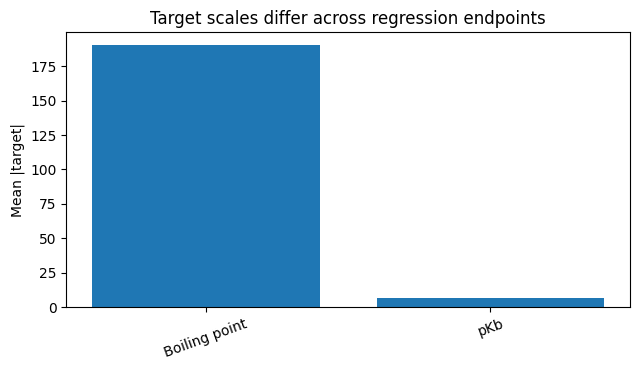

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
plot_df = target_shift_summary.copy()
ax.bar(plot_df["display"], plot_df["target_scale_all_mean_abs"])
ax.set_ylabel("Mean |target|")
ax.set_title("Target scales differ across regression endpoints")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(OUT_DIR / "target_scale_by_dataset.png", dpi=160)
plt.show()

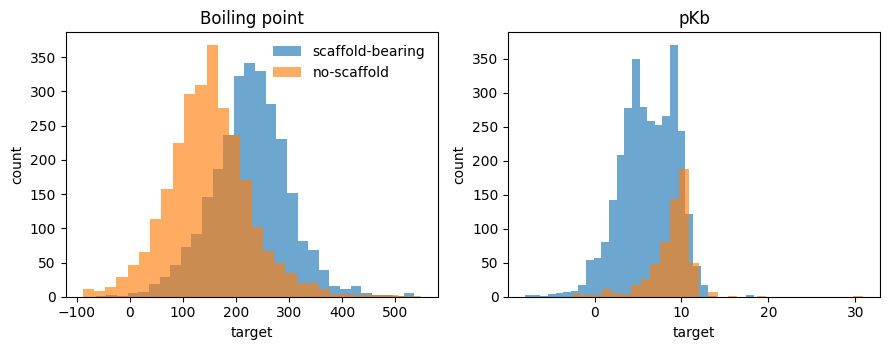

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, spec in zip(axes, DATASETS):
    folded = folded_tables[spec["dataset"]]
    target = spec["target"]
    ax.hist(folded.loc[~folded["no_scaffold"], target].astype(float), bins=30, alpha=0.65, label="scaffold-bearing")
    ax.hist(folded.loc[folded["no_scaffold"], target].astype(float), bins=30, alpha=0.65, label="no-scaffold")
    ax.set_title(spec["display"])
    ax.set_xlabel("target")
    ax.set_ylabel("count")
axes[0].legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / "target_distribution_no_scaffold_vs_scaffold_bearing.png", dpi=160)
plt.show()

## XGBoost evaluation on scaffold folds

The no-scaffold fold is evaluated on its no-scaffold test subset. Other folds provide the ordinary-fold reference.

In [9]:
prediction_tables = []
metric_rows = []

for spec in DATASETS:
    dataset = spec["dataset"]
    target = spec["target"]
    folded = folded_tables[dataset]
    ns_fold = no_scaffold_fold(folded)

    for fold in sorted(folded["fold"].unique()):
        train_df = folded.loc[folded["fold"] != fold].reset_index(drop=True)
        test_df = folded.loc[folded["fold"] == fold].reset_index(drop=True)
        preds = fit_predict_xgboost_regression(
            train_df, test_df, target_col=target, n_bits=FP_BITS,
            seed=RANDOM_SEED + int(fold), num_boost_round=NUM_BOOST_ROUND,
        )
        preds["dataset"] = dataset
        preds["display"] = spec["display"]
        preds["eval_fold"] = int(fold)
        preds["no_scaffold_fold"] = int(ns_fold)
        prediction_tables.append(preds)

        # Full fold metric.
        row = regression_metrics(preds["y_true"], preds["y_pred"])
        row.update({
            "dataset": dataset,
            "display": spec["display"],
            "eval_fold": int(fold),
            "subset": "ordinary_test_fold" if fold != ns_fold else "no_scaffold_fold_all_test",
            "is_no_scaffold_fold": bool(fold == ns_fold),
        })
        metric_rows.append(row)

        # No-scaffold subset of no-scaffold fold.
        if fold == ns_fold:
            ns_preds = preds.loc[preds["no_scaffold"]].copy()
            row = regression_metrics(ns_preds["y_true"], ns_preds["y_pred"])
            row.update({
                "dataset": dataset,
                "display": spec["display"],
                "eval_fold": int(fold),
                "subset": "no_scaffold_test_subset",
                "is_no_scaffold_fold": True,
            })
            metric_rows.append(row)

            sb_preds = preds.loc[~preds["no_scaffold"]].copy()
            if len(sb_preds) > 0:
                row = regression_metrics(sb_preds["y_true"], sb_preds["y_pred"])
                row.update({
                    "dataset": dataset,
                    "display": spec["display"],
                    "eval_fold": int(fold),
                    "subset": "scaffold_bearing_part_of_no_scaffold_fold",
                    "is_no_scaffold_fold": True,
                })
                metric_rows.append(row)

predictions = pd.concat(prediction_tables, ignore_index=True)
metrics_by_fold = pd.DataFrame(metric_rows)

predictions.to_csv(OUT_DIR / "xgboost_regression_predictions.csv", index=False)
metrics_by_fold.to_csv(OUT_DIR / "xgboost_regression_metrics_by_fold.csv", index=False)

metrics_by_fold[["dataset", "display", "eval_fold", "subset", "n", "MAE", "RMSE", "R2", "Pearson_r", "Spearman_rho", "target_scale_mean_abs", "relMAE"]]

,dataset,display,eval_fold,subset,n,MAE,RMSE,R2,Pearson_r,Spearman_rho,target_scale_mean_abs,relMAE
0,bp,Boiling point,0,ordinary_test_fold,186,45.418704,60.923565,0.496906,0.783806,0.768599,210.827151,0.215431
1,bp,Boiling point,1,ordinary_test_fold,186,51.434744,64.521880,0.518417,0.762253,0.766005,231.625269,0.222060
2,bp,Boiling point,2,ordinary_test_fold,186,59.312966,73.455313,0.306171,0.568926,0.518161,221.609677,0.267646
3,bp,Boiling point,3,ordinary_test_fold,186,44.256873,55.266861,0.346032,0.594784,0.657026,217.043280,0.203908
4,bp,Boiling point,4,ordinary_test_fold,186,48.814142,65.979378,0.514176,0.785171,0.746211,239.044113,0.204206
5,bp,Boiling point,5,ordinary_test_fold,187,47.555824,62.959187,0.302270,0.688091,0.560338,270.448824,0.175840
6,bp,Boiling point,6,no_scaffold_fold_all_test,2652,62.111799,77.484095,0.011568,0.584927,0.613661,150.886125,0.411647
7,bp,Boiling point,6,no_scaffold_test_subset,2652,62.111799,77.484095,0.011568,0.584927,0.613661,150.886125,0.411647
8,bp,Boiling point,7,ordinary_test_fold,186,50.672035,64.533969,0.469520,0.710031,0.700416,199.468011,0.254036
9,bp,Boiling point,8,ordinary_test_fold,1260,43.158666,55.222160,-0.292078,0.265402,0.182906,231.788540,0.186198


## Ordinary-fold reference vs no-scaffold subset

The ordinary reference is the median over folds that do not contain the no-scaffold bucket. The ratio table reports raw error ratio, target-scale ratio, and relMAE inflation.

In [10]:
ordinary = metrics_by_fold.loc[metrics_by_fold["subset"] == "ordinary_test_fold"].copy()
ordinary_ref = (
    ordinary
    .groupby(["dataset", "display"], as_index=False)
    .agg({
        "n": "sum",
        "MAE": "median",
        "RMSE": "median",
        "R2": "median",
        "Pearson_r": "median",
        "Spearman_rho": "median",
        "target_scale_mean_abs": "median",
        "relMAE": "median",
    })
)
ordinary_ref["subset"] = "ordinary_fold_median"

no_scaffold_eval = metrics_by_fold.loc[metrics_by_fold["subset"] == "no_scaffold_test_subset"].copy()
comparison = pd.concat([
    ordinary_ref[["dataset", "display", "subset", "n", "MAE", "RMSE", "R2", "Pearson_r", "Spearman_rho", "target_scale_mean_abs", "relMAE"]],
    no_scaffold_eval[["dataset", "display", "subset", "n", "MAE", "RMSE", "R2", "Pearson_r", "Spearman_rho", "target_scale_mean_abs", "relMAE"]],
], ignore_index=True)

ratio_rows = []
for dataset in comparison["dataset"].unique():
    ordinary_row = comparison[(comparison["dataset"] == dataset) & (comparison["subset"] == "ordinary_fold_median")].iloc[0]
    ns_row = comparison[(comparison["dataset"] == dataset) & (comparison["subset"] == "no_scaffold_test_subset")].iloc[0]
    ratio_rows.append({
        "dataset": dataset,
        "display": ordinary_row["display"],
        "MAE_ratio_no_scaffold_over_ordinary": ns_row["MAE"] / ordinary_row["MAE"],
        "RMSE_ratio_no_scaffold_over_ordinary": ns_row["RMSE"] / ordinary_row["RMSE"],
        "target_scale_ratio_no_scaffold_over_ordinary": ns_row["target_scale_mean_abs"] / ordinary_row["target_scale_mean_abs"],
        "relMAE_inflation_no_scaffold_over_ordinary": ns_row["relMAE"] / ordinary_row["relMAE"],
        "R2_drop_ordinary_minus_no_scaffold": ordinary_row["R2"] - ns_row["R2"],
        "Pearson_drop_ordinary_minus_no_scaffold": ordinary_row["Pearson_r"] - ns_row["Pearson_r"],
        "Spearman_drop_ordinary_minus_no_scaffold": ordinary_row["Spearman_rho"] - ns_row["Spearman_rho"],
    })

ratio_summary = pd.DataFrame(ratio_rows)
comparison.to_csv(OUT_DIR / "ordinary_vs_no_scaffold_regression_metrics.csv", index=False)
ratio_summary.to_csv(OUT_DIR / "ordinary_vs_no_scaffold_regression_metric_ratios.csv", index=False)

comparison


,dataset,display,subset,n,MAE,RMSE,R2,Pearson_r,Spearman_rho,target_scale_mean_abs,relMAE
0,bp,Boiling point,ordinary_fold_median,2750,47.555824,62.959187,0.469520,0.710031,0.700416,221.609677,0.215431
1,pkb,pKb,ordinary_fold_median,3071,1.946970,2.472502,0.324229,0.598166,0.638921,6.125630,0.308142
2,bp,Boiling point,no_scaffold_test_subset,2652,62.111799,77.484095,0.011568,0.584927,0.613661,150.886125,0.411647
3,pkb,pKb,no_scaffold_test_subset,591,2.351423,3.000964,-0.343654,0.343658,0.259256,8.897039,0.264293


In [11]:
ratio_summary

,dataset,display,MAE_ratio_no_scaffold_over_ordinary,RMSE_ratio_no_scaffold_over_ordinary,target_scale_ratio_no_scaffold_over_ordinary,relMAE_inflation_no_scaffold_over_ordinary,R2_drop_ordinary_minus_no_scaffold,Pearson_drop_ordinary_minus_no_scaffold,Spearman_drop_ordinary_minus_no_scaffold
0,bp,Boiling point,1.306082,1.230704,0.680864,1.910806,0.457952,0.125104,0.086754
1,pkb,pKb,1.207734,1.213736,1.452428,0.857698,0.667884,0.254508,0.379666


## Metric plots

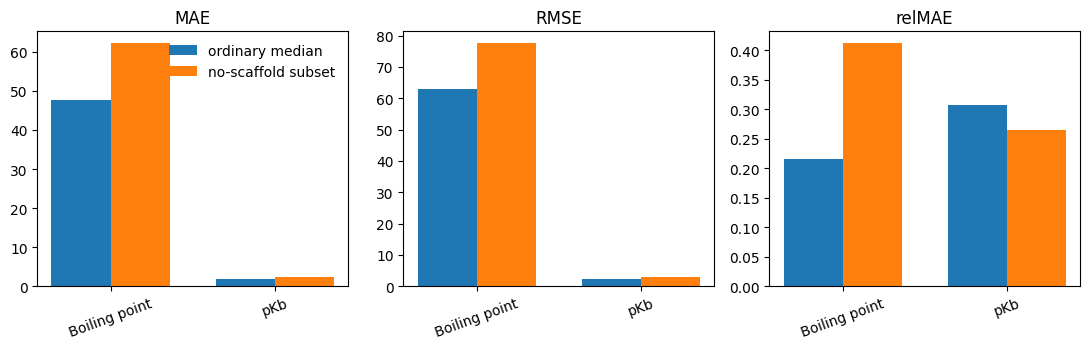

In [12]:
plot_metrics = ["MAE", "RMSE", "relMAE"]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, metric in zip(axes, plot_metrics):
    x = np.arange(len(DATASETS))
    width = 0.36
    ord_vals = []
    ns_vals = []
    labels = []
    for spec in DATASETS:
        labels.append(spec["display"])
        ord_vals.append(float(comparison[(comparison["dataset"] == spec["dataset"]) & (comparison["subset"] == "ordinary_fold_median")][metric].iloc[0]))
        ns_vals.append(float(comparison[(comparison["dataset"] == spec["dataset"]) & (comparison["subset"] == "no_scaffold_test_subset")][metric].iloc[0]))
    ax.bar(x - width / 2, ord_vals, width, label="ordinary median")
    ax.bar(x + width / 2, ns_vals, width, label="no-scaffold subset")
    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20)
axes[0].legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / "ordinary_vs_no_scaffold_error_metrics.png", dpi=160)
plt.show()

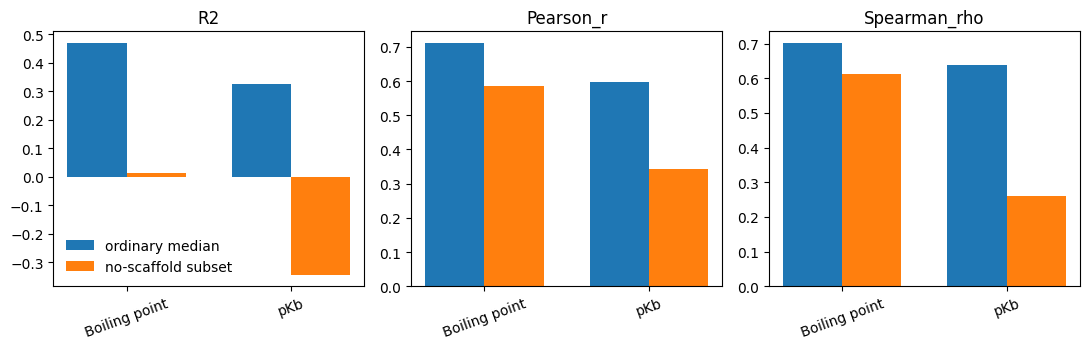

In [13]:
plot_metrics = ["R2", "Pearson_r", "Spearman_rho"]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, metric in zip(axes, plot_metrics):
    x = np.arange(len(DATASETS))
    width = 0.36
    ord_vals = []
    ns_vals = []
    labels = []
    for spec in DATASETS:
        labels.append(spec["display"])
        ord_vals.append(float(comparison[(comparison["dataset"] == spec["dataset"]) & (comparison["subset"] == "ordinary_fold_median")][metric].iloc[0]))
        ns_vals.append(float(comparison[(comparison["dataset"] == spec["dataset"]) & (comparison["subset"] == "no_scaffold_test_subset")][metric].iloc[0]))
    ax.bar(x - width / 2, ord_vals, width, label="ordinary median")
    ax.bar(x + width / 2, ns_vals, width, label="no-scaffold subset")
    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20)
axes[0].legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / "ordinary_vs_no_scaffold_association_metrics.png", dpi=160)
plt.show()

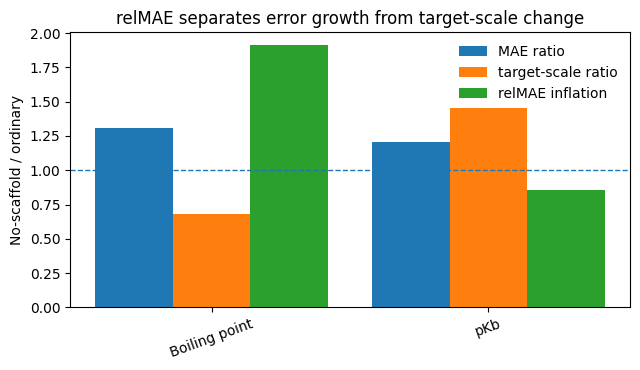

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
x = np.arange(len(ratio_summary))
width = 0.28
ax.bar(x - width, ratio_summary["MAE_ratio_no_scaffold_over_ordinary"], width, label="MAE ratio")
ax.bar(x, ratio_summary["target_scale_ratio_no_scaffold_over_ordinary"], width, label="target-scale ratio")
ax.bar(x + width, ratio_summary["relMAE_inflation_no_scaffold_over_ordinary"], width, label="relMAE inflation")
ax.axhline(1.0, linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(ratio_summary["display"], rotation=20)
ax.set_ylabel("No-scaffold / ordinary")
ax.set_title("relMAE separates error growth from target-scale change")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / "relmae_inflation_decomposition.png", dpi=160)
plt.show()

## Generated files

The notebook writes results under `outputs/notebooks/regression_metric_comparison/`.

Main tables:
- `target_shift_summary.csv`
- `xgboost_regression_metrics_by_fold.csv`
- `ordinary_vs_no_scaffold_regression_metrics.csv`
- `ordinary_vs_no_scaffold_regression_metric_ratios.csv`

Figures:
- target-scale summary
- target-distribution histograms
- metric comparisons
- relMAE decomposition

In [15]:
print("Saved files:")
for path in sorted(OUT_DIR.iterdir()):
    print("-", path.relative_to(PROJECT_ROOT))

Saved files:
- outputs/notebooks/regression_metric_comparison/ordinary_vs_no_scaffold_association_metrics.png
- outputs/notebooks/regression_metric_comparison/ordinary_vs_no_scaffold_error_metrics.png
- outputs/notebooks/regression_metric_comparison/ordinary_vs_no_scaffold_regression_metric_ratios.csv
- outputs/notebooks/regression_metric_comparison/ordinary_vs_no_scaffold_regression_metrics.csv
- outputs/notebooks/regression_metric_comparison/relmae_inflation_decomposition.png
- outputs/notebooks/regression_metric_comparison/scaffold_fold_allocation_summary.csv
- outputs/notebooks/regression_metric_comparison/target_distribution_no_scaffold_vs_scaffold_bearing.png
- outputs/notebooks/regression_metric_comparison/target_scale_by_dataset.png
- outputs/notebooks/regression_metric_comparison/target_shift_summary.csv
- outputs/notebooks/regression_metric_comparison/xgboost_regression_metrics_by_fold.csv
- outputs/notebooks/regression_metric_comparison/xgboost_regression_predictions.csv
